In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, accuracy_score

In [5]:
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")

In [6]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived

In [7]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [9]:
mp = mp[mp>0].sort_values()
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [10]:
df_train["Age"].median()

28.0

In [11]:
df_train["Fare"].median()

14.4542

In [12]:
df_train = df_train.dropna(axis = 0, subset= ["Embarked"])

In [13]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())


In [14]:
df_train = df_train.drop(["Cabin"], axis = 1)

In [15]:
df_test = df_test.dropna(axis = 0, subset= ["Fare"])

In [16]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

In [17]:
df_test = df_test.drop(["Cabin"], axis = 1)

In [18]:
df_train.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)
df_test.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)

In [19]:
df_train["Survived"] = df_train["Survived"].apply(str)
df_train["Pclass"] = df_train["Pclass"].apply(str)

df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)


In [20]:
df_train_num = df_train.select_dtypes(exclude = "object")
df_train_obj = df_train.select_dtypes(include = "object")

df_test_num = df_test.select_dtypes(exclude = "object")
df_test_obj = df_test.select_dtypes(include = "object")

In [21]:
df_train_obj = pd.get_dummies(df_train_obj, drop_first = True)
df_test_obj = pd.get_dummies(df_test_obj, drop_first = True)

In [22]:
Final_train_df = pd.concat([df_train_num,df_train_obj, df_train["Survived"]], axis=1)
Final_test_df = pd.concat([df_test_num,df_test_obj, df_test["Survived"]], axis=1)

In [23]:
X_train = Final_train_df.drop("Survived", axis =1)
y_train = Final_train_df["Survived"]

X_test = Final_test_df.drop("Survived", axis =1)
y_tes = Final_test_df["Survived"]

In [24]:
scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)


In [25]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(scaled_X_train, y_train)

y_pred = knn.predict(scaled_X_test)

accuracy_score(y_tes, y_pred)

0.9928057553956835

In [26]:
Performance_Metric = []

for k in range(1,30):

    knn_k = KNeighborsClassifier(n_neighbors=k)

    knn_k.fit(scaled_X_train, y_train)

    y_pred_k = knn_k.predict(scaled_X_test)

    accuracy_k = 1-accuracy_score(y_tes, y_pred_k)

    Performance_Metric.append(accuracy_k)

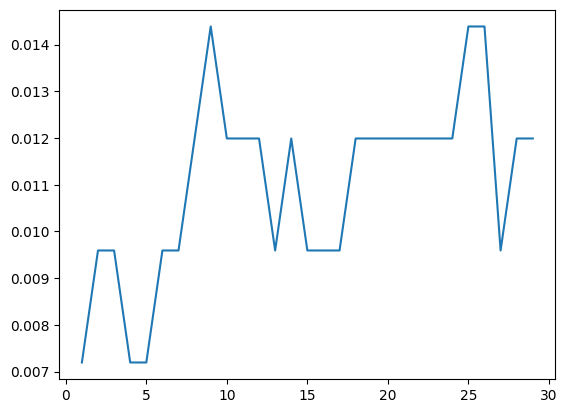

In [27]:
plt.plot(range(1,30), Performance_Metric)

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(scaled_X_train, y_train)

y_pred_lr = lr.predict(scaled_X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_tes, y_pred_lr))

Logistic Regression Accuracy: 1.0


In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)

print("Decision Tree Accuracy:", accuracy_score(y_tes, y_pred_dt))


Decision Tree Accuracy: 1.0


In [30]:
print("KNN Accuracy:", accuracy_score(y_tes, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_tes, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_tes, y_pred_dt))

KNN Accuracy: 0.9928057553956835
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


The Titanic dataset was analyzed using KNN, Logistic Regression, and Decision Tree algorithms.

Data preprocessing included handling missing values, removing unnecessary features, and converting categorical variables into dummy variables.

The dataset was standardized using StandardScaler before training.

The performance of the models was compared using accuracy, and Logistic Regression and Decision Tree achieved the highest accuracy.